# Ridge and Lasso with scikit-learn

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

Regularization fights overfitting by penalizing large weights during training: an L2 penalty shrinks all weights toward zero, an L1 penalty drives the least useful weights to exactly zero, and <b>Ridge</b> and <b>Lasso</b> are the names for linear regression with those penalties built in. In this notebook you will use them both on real data.

The plan: take a small dataset, engineer it into far more features than the data can justify, watch plain linear regression overfit, and then use Ridge and Lasso to fix it. Along the way you will choose the regularization strength <code>alpha</code> the standard way, with a validation sweep, and see Lasso act as an automatic feature selector.

</div>

---
## Step 1: The Data: Predicting Fuel Economy

We predict a car's fuel economy in miles per gallon (mpg) from its physical specs: engine cylinders, displacement, horsepower, weight, acceleration, and model year. The dataset covers about 400 cars from the 1970s and early 1980s.

> **Data source:** The Auto MPG dataset from the UCI Machine Learning Repository, distributed with this course as `auto_mpg.csv`. Download it from the course folder and place it in the same directory as this notebook.

A handful of rows have a missing horsepower value. Imputing them would be perfectly reasonable, but they are less than 2% of the data and preprocessing is not today's topic, so we drop them and keep the focus on regularization.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

RANDOM_SEED = 23

df = pd.read_csv('auto_mpg.csv')
print(f"Rows loaded: {len(df)}, missing horsepower: {df['horsepower'].isna().sum()}")
df = df.dropna()
print(f"Rows after dropping missing values: {len(df)}")

feature_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
X_raw = df[feature_cols]
y = df['mpg']

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y, test_size=0.3, random_state=RANDOM_SEED)
print(f"Training rows: {len(X_train_raw)}, validation rows: {len(X_val_raw)}")

Rows loaded: 398, missing horsepower: 6
Rows after dropping missing values: 392
Training rows: 274, validation rows: 118


---
## Step 2: A Baseline, Then Many More Features

First, a plain linear regression on the six raw features, as a baseline. Then we add far more features than the data can support: `PolynomialFeatures(degree=3)` expands the six features into every square, cube, and interaction, 83 columns in total. Relationships like mpg vs. weight really are curved, so some of these features are genuinely useful. Most are not.

One rule to notice in the code: we scale **after** expanding, and fit the scaler on training data only. Regularization penalizes every weight by the same formula, so all features must live on a comparable scale; otherwise the penalty punishes features for their units instead of their usefulness.

In [ ]:
def prepare_features(degree):
    """Expand to polynomial features of the given degree, then scale. Fit on train only."""
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()

    poly.fit(X_train_raw)
    X_train_poly = poly.transform(X_train_raw)
    X_val_poly = poly.transform(X_val_raw)

    scaler.fit(X_train_poly)
    X_train = scaler.transform(X_train_poly)
    X_val = scaler.transform(X_val_poly)
    return X_train, X_val, poly

def rmse_report(model, X_train, X_val):
    """Return (train_rmse, val_rmse) for a fitted model."""
    train_rmse = root_mean_squared_error(y_train, model.predict(X_train))
    val_rmse = root_mean_squared_error(y_val, model.predict(X_val))
    return train_rmse, val_rmse


# Baseline: straight linear regression on the 6 raw features
X_train_1, X_val_1, _ = prepare_features(degree=1)
ols_baseline = LinearRegression().fit(X_train_1, y_train)
base_train, base_val = rmse_report(ols_baseline, X_train_1, X_val_1)
print(f"degree 1, {X_train_1.shape[1]} features: train RMSE {base_train:.2f}, val RMSE {base_val:.2f}")

# The explosion: degree 3
X_train_3, X_val_3, poly_3 = prepare_features(degree=3)
ols_poly = LinearRegression().fit(X_train_3, y_train)
poly_train, poly_val = rmse_report(ols_poly, X_train_3, X_val_3)
print(f"degree 3, {X_train_3.shape[1]} features: train RMSE {poly_train:.2f}, val RMSE {poly_val:.2f}")
print(f"rows per feature: {len(y_train) / X_train_3.shape[1]:.1f}")
print(f"largest |weight| of the degree-3 model: {np.abs(ols_poly.coef_).max():,.0f}")

degree 1, 6 features: train RMSE 3.46, val RMSE 3.42
degree 3, 83 features: train RMSE 1.99, val RMSE 4.17
rows per feature: 3.3
largest |weight| of the degree-3 model: 3,362


> **Note:** The baseline predicts within about 3.4 mpg and shows no gap (train 3.46, validation 3.42). The degree-3 model looks excellent on the training set (1.99) and much worse on validation (4.17), worse even than the baseline. That is overfitting on real data, and both warning signs you know are present: 274 training rows for 83 features is about 3.3 rows per feature, far below the ten-per-feature rule of thumb, and the model needed a weight of over 3,000 (on standardized features!) to fit the training points so closely.

---
## Step 3: Ridge: Shrink the Weights

Ridge is linear regression plus the L2 penalty. In simplified form, training minimizes one combined quantity:

```
total loss = training error + alpha * (sum of squared weights)
```

That single line explains two things you are about to see. `alpha` multiplies the penalty, so it directly sets how hard weights are pushed toward zero: larger alpha means stronger shrinking. And every weight enters the same sum, which is why the features had to share a scale first. (If you are thinking of logistic regression's `C`, remember the conventions point in opposite directions: larger alpha but smaller C mean stronger regularization.)

There is no way to know the right alpha in advance. The standard approach is a validation sweep: fit the model at a range of alphas, spaced by factors of 10, and plot training and validation error against alpha. This is a validation curve, the same diagnostic you use for any complexity dial.

alpha=1e-08    train RMSE 1.99   val RMSE 4.16
alpha=1e-07    train RMSE 1.99   val RMSE 4.14
alpha=1e-06    train RMSE 1.99   val RMSE 3.97
alpha=1e-05    train RMSE 2.04   val RMSE 3.38
alpha=0.0001   train RMSE 2.16   val RMSE 2.89
alpha=0.001    train RMSE 2.30   val RMSE 2.77
alpha=0.01     train RMSE 2.41   val RMSE 2.76
alpha=0.1      train RMSE 2.53   val RMSE 2.76
alpha=1        train RMSE 2.66   val RMSE 2.80
alpha=10       train RMSE 2.78   val RMSE 2.84
alpha=100      train RMSE 3.01   val RMSE 2.98
alpha=1000     train RMSE 3.89   val RMSE 3.51


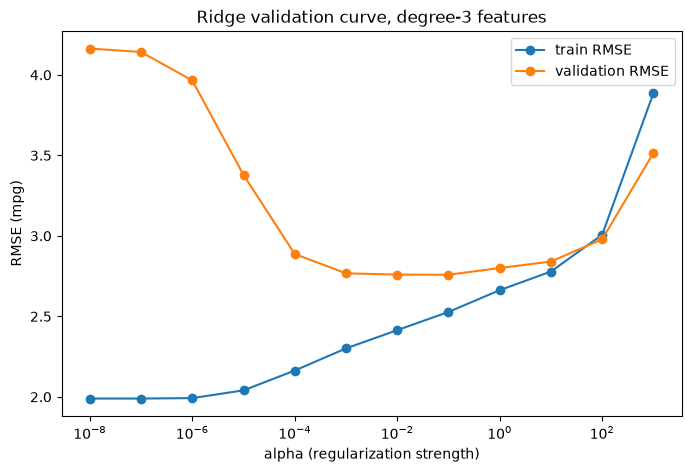

largest |weight| at alpha=0.1: 9.8


In [3]:
alphas = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]
ridge_train, ridge_val = [], []
for alpha in alphas:
    model = Ridge(alpha=alpha).fit(X_train_3, y_train)
    tr, va = rmse_report(model, X_train_3, X_val_3)
    ridge_train.append(tr)
    ridge_val.append(va)
    print(f"alpha={alpha:<8} train RMSE {tr:.2f}   val RMSE {va:.2f}")

plt.figure(figsize=(8, 5))
# semilogx: log-scaled x-axis, so each factor of 10 in alpha is one equal step
plt.semilogx(alphas, ridge_train, 'o-', label='train RMSE')
plt.semilogx(alphas, ridge_val, 'o-', label='validation RMSE')
plt.xlabel('alpha (regularization strength)')
plt.ylabel('RMSE (mpg)')
plt.title('Ridge validation curve, degree-3 features')
plt.legend()
plt.show()

ridge_best = Ridge(alpha=0.1).fit(X_train_3, y_train)
print(f"largest |weight| at alpha=0.1: {np.abs(ridge_best.coef_).max():.1f}")

> **Note:** Read the curve from left to right. At alpha=1e-8 the penalty is so weak that the model is effectively unregularized: validation RMSE 4.16, the overfitting result from Step 2. As alpha grows, validation error falls into a wide plateau around 2.76 to 2.77 for alphas between 0.001 and 0.1, and then rises again once the penalty is so strong the model underfits (3.51 at alpha=1000). The best validation score beats the baseline by a clear margin: the polynomial features genuinely help, but only once regularization stops them from being memorized. Note also the largest weight: about 10 instead of 3,000.
>
> As with any validation curve, trust the plateau rather than a single winning point. Any alpha in the flat region is a reasonable choice; we take 0.1.

---
## Step 4: Lasso: Shrink Some Weights to Zero

Lasso is linear regression plus the L1 penalty: instead of the squares in the penalty we use absolute values (`total loss = training error + alpha * (sum of |weights|)`), and that seemingly small change drags small weights all the way to exactly zero. Same workflow: sweep alpha, watch validation error, and this time also count how many features the model throws away.

One new practical detail: `max_iter`. Lasso is fit by an iterative optimizer, and `max_iter` is its iteration budget, the same idea as the epoch count you used when implementing gradient descent. The optimizer stops when it converges or when the budget runs out, whichever comes first.

In [11]:
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1]
for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, max_iter=50000).fit(X_train_3, y_train)
    tr, va = rmse_report(model, X_train_3, X_val_3)
    n_zero = (model.coef_ == 0).sum()
    print(f"alpha={alpha:<7} train RMSE {tr:.2f}   val RMSE {va:.2f}   zeroed {n_zero}/{len(model.coef_)} features")

/Users/marcus/ml-course/.venv/lib/python3.14t/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.504601e+02, tolerance: 1.820e+00
  model = cd_fast.enet_coordinate_descent(


alpha=0.0001  train RMSE 2.38   val RMSE 2.80   zeroed 6/83 features
alpha=0.001   train RMSE 2.48   val RMSE 2.74   zeroed 47/83 features
alpha=0.01    train RMSE 2.70   val RMSE 2.79   zeroed 66/83 features
alpha=0.1     train RMSE 2.91   val RMSE 2.90   zeroed 71/83 features
alpha=1       train RMSE 3.53   val RMSE 3.07   zeroed 78/83 features


/Users/marcus/ml-course/.venv/lib/python3.14t/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.244654e+01, tolerance: 1.820e+00
  model = cd_fast.enet_coordinate_descent(


  > **Note:** You likely saw a `ConvergenceWarning` for the smallest alphas. That is the optimizer reporting that it used up `max_iter` iterations before fully converging: with 83 correlated columns and almost no regularization, the optimization problem is at its hardest. You could raise `max_iter` further, but the scores are stable, and alphas that tiny are nearly unregularized anyway, so the warning is safe to acknowledge and move past. It becomes a problem only when the reported numbers change as you raise the budget.
  >
  > The sweet spot sits at alpha=0.001 (validation RMSE 2.74, the best score yet); weaker regularization scores slightly worse (2.80 at alpha=0.0001), and large alphas underfit (3.07 at alpha=1). We did not test alphas tiny enough to fall all the way back to the unregularized 4.17, but the left edge already points in that direction. The new column is the interesting one: at the sweet spot, Lasso set 47 of the 83 weights to exactly zero. The model chose to use 36 features and discard the rest.

In [ ]:
lasso_best = Lasso(alpha=0.001, max_iter=50000).fit(X_train_3, y_train)
feature_names = poly_3.get_feature_names_out(feature_cols)

kept = [(name, coef) for name, coef in zip(feature_names, lasso_best.coef_) if coef != 0]
kept.sort(key=lambda pair: -abs(pair[1]))   # sort by |weight|, largest first

print(f"Features kept: {len(kept)} of {len(feature_names)}")
print("\nTop 8 by |weight|:")
for name, coef in kept[:8]:
    print(f"  {name:<40} {coef:>8.2f}")

Features kept: 36 of 83

Top 8 by |weight|:
  cylinders displacement                     -31.50
  horsepower acceleration model_year         -21.71
  displacement acceleration^2                -17.26
  displacement^2 acceleration                 16.75
  acceleration^2 model_year                   13.86
  horsepower acceleration                     13.67
  model_year^3                                10.11
  cylinders^2 model_year                      -8.57


/Users/marcus/ml-course/.venv/lib/python3.14t/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.244654e+01, tolerance: 1.820e+00
  model = cd_fast.enet_coordinate_descent(


> **Note:** The survivors are dominated by interactions of displacement, cylinders, horsepower, acceleration, and model year, which is plausible: fuel economy really is driven by combinations of engine size and era. One caution before you read too much into the list: when several features are highly correlated, as polynomial expansions always are, Lasso keeps one member of the group somewhat arbitrarily and zeroes the others. Read the surviving set as "sufficient to predict well," not as "the true causes."

---
## Step 5: ElasticNet: The Middle Ground

There is a third option you should recognize by name. **ElasticNet** combines both penalties in one model, with `l1_ratio` setting the mix: `l1_ratio=1` is pure L1 (Lasso), `l1_ratio=0` is pure L2 (Ridge), and values in between blend the two. It is popular when you want some feature selection but with correlated feature groups treated more stably than pure Lasso treats them. Awareness is enough for now; one fit to see it work:

In [6]:
enet = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=50000).fit(X_train_3, y_train)
tr, va = rmse_report(enet, X_train_3, X_val_3)
print(f"ElasticNet(alpha=0.001, l1_ratio=0.5): train RMSE {tr:.2f}, val RMSE {va:.2f}, "
      f"zeroed {(enet.coef_ == 0).sum()}/{len(enet.coef_)}")

ElasticNet(alpha=0.001, l1_ratio=0.5): train RMSE 2.56, val RMSE 2.76, zeroed 14/83


/Users/marcus/ml-course/.venv/lib/python3.14t/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.456645e+02, tolerance: 1.820e+00
  model = cd_fast.enet_coordinate_descent(


---
## Step 6: Comparing All Models

All models side by side, evaluated on the same validation set:

In [7]:
results = [
    ('degree 1, LinearRegression', ols_baseline, X_train_1, X_val_1),
    ('degree 3, LinearRegression', ols_poly, X_train_3, X_val_3),
    ('degree 3, Ridge(alpha=0.1)', ridge_best, X_train_3, X_val_3),
    ('degree 3, Lasso(alpha=0.001)', lasso_best, X_train_3, X_val_3),
    ('degree 3, ElasticNet(0.001, 0.5)', enet, X_train_3, X_val_3),
]
print(f"{'model':<35} {'train RMSE':>10} {'val RMSE':>9}")
for name, model, X_tr, X_va in results:
    tr, va = rmse_report(model, X_tr, X_va)
    print(f"{name:<35} {tr:>10.2f} {va:>9.2f}")

model                               train RMSE  val RMSE
degree 1, LinearRegression                3.46      3.42
degree 3, LinearRegression                1.99      4.17
degree 3, Ridge(alpha=0.1)                2.53      2.76
degree 3, Lasso(alpha=0.001)              2.48      2.74
degree 3, ElasticNet(0.001, 0.5)          2.56      2.76


> **Note:** The table summarizes the whole experiment. Adding rich features to plain linear regression made it *worse* than the six-feature baseline (4.17 vs. 3.42). The same rich features under regularization gave the best models in the experiment (2.74 to 2.76). Regularization did not just repair the overfitting; it unlocked the value of the features that caused it. That combination, generous features plus a tuned penalty, is a very common and reliable approach in classical machine learning.

---
## YOUR TURN

<div style="background-color:#1e293b;padding:15px;border-left:6px solid #38bdf8;color:#e2e8f0">

<b>Exercise: When does regularization stop mattering?</b>

Degree 3 added an extreme number of features. Test a milder version:

1. Rerun the notebook with <code>degree=2</code> wherever degree 3 was used (27 features instead of 83). Record the train and validation RMSE of plain <code>LinearRegression</code>, and the best validation RMSE you can get from Ridge and from Lasso.

2. Compare the degree-2 situation to the degree-3 one: how big is the overfitting gap now, and how much does regularization improve validation RMSE?

3. In two or three sentences: when does regularization buy you the most, and what evidence from this notebook supports your answer?

</div>

In [8]:
# YOUR TURN
# 1. Rebuild the features with degree=2 and refit:
#    X_train_2, X_val_2, poly_2 = prepare_features(degree=2)
#    - plain LinearRegression: train and val RMSE?
#    - Ridge: sweep alphas, best val RMSE?
#    - Lasso: sweep alphas, best val RMSE?
# 2. Compare against the degree-3 numbers from the scoreboard above.
# 3. Your conclusion (as comments or a markdown cell):
#    - When does regularization buy the most?

<details><summary><b>Click for Solution</b></summary>

```python
X_train_2, X_val_2, poly_2 = prepare_features(degree=2)

ols_2 = LinearRegression().fit(X_train_2, y_train)
print(rmse_report(ols_2, X_train_2, X_val_2))

for alpha in [0.001, 0.01, 0.1, 1, 10]:
    r = Ridge(alpha=alpha).fit(X_train_2, y_train)
    l = Lasso(alpha=alpha, max_iter=50000).fit(X_train_2, y_train)
    print(alpha, rmse_report(r, X_train_2, X_val_2)[1], rmse_report(l, X_train_2, X_val_2)[1])
```

With degree 2, plain LinearRegression scores about 2.63 on train and 2.81 on validation: a small gap, and already better than the degree-1 baseline. The best Ridge lands around 2.78 and the best Lasso around 2.76, improvements of a few hundredths of an mpg rather than the 1.4 mpg improvement you saw at degree 3.

That is the general pattern. Regularization matters most when model capacity is large relative to the data: many features per row, heavy feature engineering, a big train-validation gap. At degree 2 there was little overfitting to fix, so there was little for the penalty to recover. Notice also that a well-regularized degree-3 model (2.74) and a modest degree-2 model (2.76 to 2.81) end up in the same neighborhood: you can get there either by hand-limiting complexity or by regularizing generous complexity. The regularized route required less guessing about which features to allow.

</details>

---
## What You Should Be Able to Do Now

- Fit `Ridge` and `Lasso` and explain what their `alpha` controls.
- Choose alpha with a validation sweep and defend a value from the stable plateau.
- Explain why features must be scaled before a regularized model, and why the scaler is fit on training data only.
- Read Lasso's zeroed weights as automatic feature selection, with the correlated-features caveat.
- Say when regularization matters most, and support it with the degree-2 vs. degree-3 evidence.
- Recognize `ElasticNet` and its `l1_ratio` as the blend of the two penalties.